# Single Dot with 1/f Charge Noise — 10 Realisations

This notebook simulates a **single quantum dot** coupled to an RLC readout resonator.  
A large-amplitude **1/f (pink) noise** trajectory is applied to the charge sensor's energy offset at each realisation, mimicking real charge-noise environments.

We run **10 independent realisations** and plot the demodulated **I** and **Q** quadratures for each.

## 1 · Imports

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.join('..', 'src'))
from readout_simulator import QuantumDotSystem, RLC_sensor
from readout_simulator.noise_models import OU_noise, SpectrumNoise

print("Imports OK")

Imports OK


## 2 · Physical System & Sensor

One quantum dot (`Cdd`, `Cds`), one RLC sensor parked **on the flank** of the Coulomb peak (`eps0 = 0.5 × eps_width`) so that charge noise translates into the largest possible IQ modulation.

In [6]:
# ── Dot layout ──────────────────────────────────────────────────────────────
Cdd = np.array([[1.0]])   # self-capacitance matrix (1 dot)
Cds = np.array([[0.5]])   # dot-sensor coupling

dot_system = QuantumDotSystem(Cdd, Cds)

# ── RLC sensor ───────────────────────────────────────────────────────────────
sensor_params = {
    'Lc'  : 800e-9,   # inductance  [H]
    'Cp'  : 0.5e-12,  # parasitic capacitance [F]
    'RL'  : 40,       # load resistance [Ω]
    'Rc'  : 0,        # coupling resistance (parallel tank)
    'Z0'  : 50,       # line impedance [Ω]
}
peak_params = {
    'g0'       : 1/50,  # peak conductance [S]
    'eps0'     : 0.5,   # operating point (in units of eps_width) — on the flank
    'eps_width': 1.0,   # Coulomb peak width [a.u.]
}

sensor = RLC_sensor(sensor_params, peak_params)
print(f"Resonant frequency: {sensor.f0/1e9:.3f} GHz")

Dot-sensor coupling strength (Δε/ε_w): [[0.5]]
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: None
Resonant frequency: 0.252 GHz


## 3 · Noise Model — Two Options

**Option A — `OU_noise`:** single Ornstein–Uhlenbeck process; exponential autocorrelation.

**Option B — `SpectrumNoise`:** provide any PSD function $S(f)$; the trajectory is synthesised in the frequency domain and normalised to a target $\sigma$ in units of the Coulomb peak width.

Switch `NOISE_OPTION` below to try each one.

In [ ]:
# ── Simulation time axis ─────────────────────────────────────────────────────
times    = np.arange(0, 1e-6, 0.25e-9)   # 1 µs, 0.25 ns steps
times_ns = times * 1e9                    # for plotting

# ── Choose noise option ───────────────────────────────────────────────────────
#   'OU'       → single Ornstein–Uhlenbeck process
#   'spectrum' → synthesised from a 1/f PSD (no JAX required)
NOISE_OPTION = 'spectrum'

# --- sigma: RMS amplitude in units of eps_width (large → visible IQ drift) ---
NOISE_SIGMA = 0.5

if NOISE_OPTION == 'OU':
    # Correlation time ~10 ns — fast fluctuations
    noise_model = OU_noise(sigma=NOISE_SIGMA, gamma=1 / 10e-9)
    def make_noise(k):
        import jax, jax.numpy as jnp
        return np.array(noise_model.generate_trajectory(
            jax.random.PRNGKey(k), jnp.array(times)))

elif NOISE_OPTION == 'spectrum':
    # 1/f PSD:  S(f) = 1/|f|  (regularised at DC)
    def psd_1f(freqs):
        return np.where(freqs > 0, 1.0 / freqs, 0.0)

    noise_model = SpectrumNoise(psd_func=psd_1f, sigma=NOISE_SIGMA)
    def make_noise(k):
        return noise_model.generate_trajectory(times, seed=k)

print(f"Noise option: {NOISE_OPTION},  σ = {NOISE_SIGMA} × eps_width")

1/f noise model ready


## 4 · Run 10 Realisations

Each realisation draws a fresh 1/f noise trajectory (different JAX seed) and runs the full ODE simulation with `use_stationary_initial_state=True` to avoid the ring-up transient.

In [ ]:
N_REAL = 10
charge_state = np.array([1])   # one electron in the dot
params       = {'eps0': 0.0}   # operating point set inside sensor (eps0 = 0.5)

I_all     = np.zeros((N_REAL, len(times)))
Q_all     = np.zeros((N_REAL, len(times)))
noise_all = np.zeros((N_REAL, len(times)))

for k in range(N_REAL):
    print(f"  Realisation {k+1}/{N_REAL} ...", end=" ")

    noise_traj = make_noise(k)   # uses whichever option is selected above

    I, Q, _, _ = sensor.get_signal(
        times                        = times,
        dot_system                   = dot_system,
        charge_state                 = charge_state,
        sensor_index                 = 0,
        params                       = params,
        noise_trajectory             = noise_traj,
        use_stationary_initial_state = True,
    )

    I_all[k]     = I
    Q_all[k]     = Q
    noise_all[k] = noise_traj
    print("done")

print("\nAll realisations complete.")

  Realisation 1/10 ... 1.0
done
  Realisation 2/10 ... 1.0
done
  Realisation 3/10 ... 1.0
done
  Realisation 4/10 ... 1.0
done
  Realisation 5/10 ... 1.0
done
  Realisation 6/10 ... 1.0
done
  Realisation 7/10 ... 1.0
done
  Realisation 8/10 ... 1.0
done
  Realisation 9/10 ... 1.0
done
  Realisation 10/10 ... 1.0
done

All realisations complete.


## 5 · Plot: I and Q Time Traces

Each row shows one realisation. The **noise trajectory** driving that run is shown in grey as a reference.

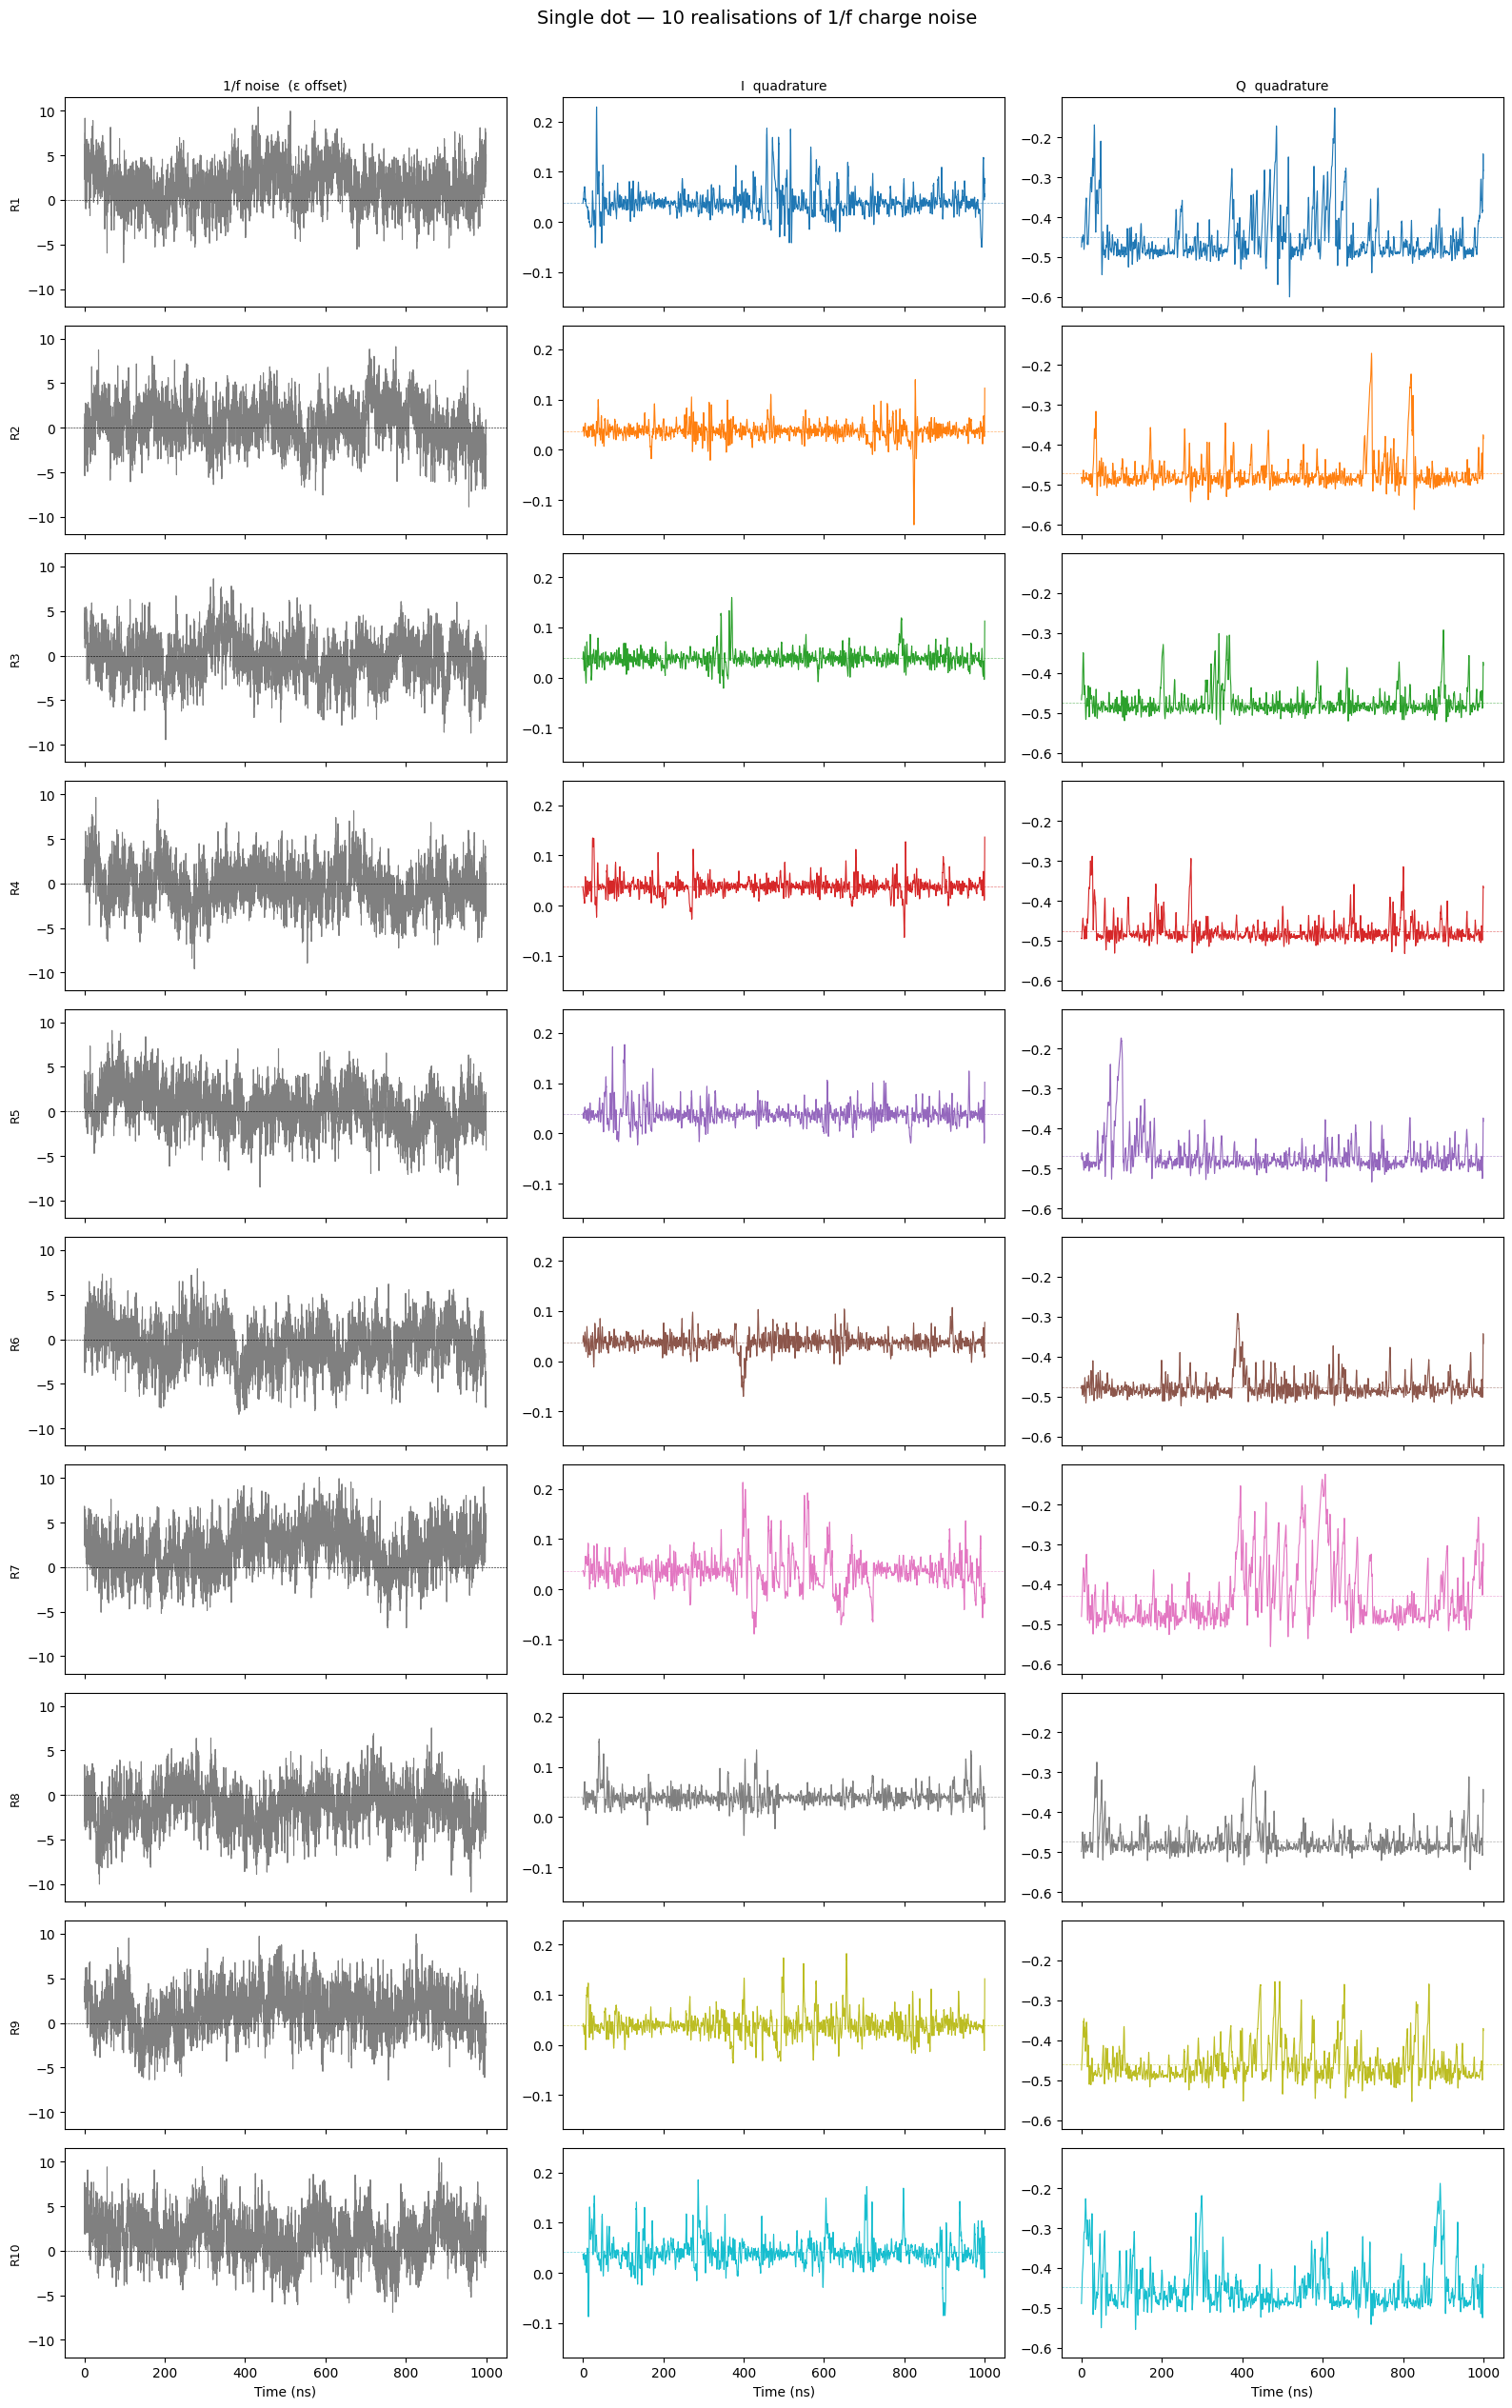

In [9]:
colors = plt.cm.tab10(np.linspace(0, 1, N_REAL))

fig, axes = plt.subplots(N_REAL, 3, figsize=(16, 2.5 * N_REAL),
                         sharex=True, sharey='col')
fig.suptitle("Single dot — 10 realisations of 1/f charge noise", fontsize=14, y=1.01)

for k in range(N_REAL):
    c = colors[k]
    ax_noise, ax_I, ax_Q = axes[k]

    # --- 1/f noise driving this realisation ---
    ax_noise.plot(times_ns, noise_all[k], color='grey', lw=0.8)
    ax_noise.set_ylabel(f"R{k+1}", fontsize=9)
    ax_noise.axhline(0, color='k', lw=0.4, ls='--')
    if k == 0:
        ax_noise.set_title("1/f noise  (ε offset)", fontsize=10)

    # --- I quadrature ---
    ax_I.plot(times_ns, I_all[k], color=c, lw=0.8)
    ax_I.axhline(np.mean(I_all[k]), color=c, lw=0.5, ls='--', alpha=0.6)
    if k == 0:
        ax_I.set_title("I  quadrature", fontsize=10)

    # --- Q quadrature ---
    ax_Q.plot(times_ns, Q_all[k], color=c, lw=0.8)
    ax_Q.axhline(np.mean(Q_all[k]), color=c, lw=0.5, ls='--', alpha=0.6)
    if k == 0:
        ax_Q.set_title("Q  quadrature", fontsize=10)

axes[-1, 0].set_xlabel("Time (ns)")
axes[-1, 1].set_xlabel("Time (ns)")
axes[-1, 2].set_xlabel("Time (ns)")

plt.tight_layout()
plt.show()